# Data Analysis

## Mounting Drive and Importing Libraries

In [1]:
# mounting drive
from google.colab import drive
drive.mount("/content/drive")

# importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Mounted at /content/drive


## Moth Data

### Loading the Dataset

In [2]:
# loading data
path = "/content/drive/MyDrive/Colab Notebooks/SCC 450 - Group Project/Week 10/Data/Primary Moth Data CLEAN.csv"
df = pd.read_csv(path)

# converting to dates properly n extracting
df['SDATE'] = pd.to_datetime(df['SDATE'], format='%Y-%m-%d', errors='coerce')
df['YEAR'] = df['SDATE'].dt.year

# making sure VALUE is numeric
df['VALUE'] = pd.to_numeric(df['VALUE'], errors='coerce')

# extract month number
df['MONTH'] = df['SDATE'].dt.month



/tmp/ipython-input-4225424719.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


### Species Abundance (Site-wise)

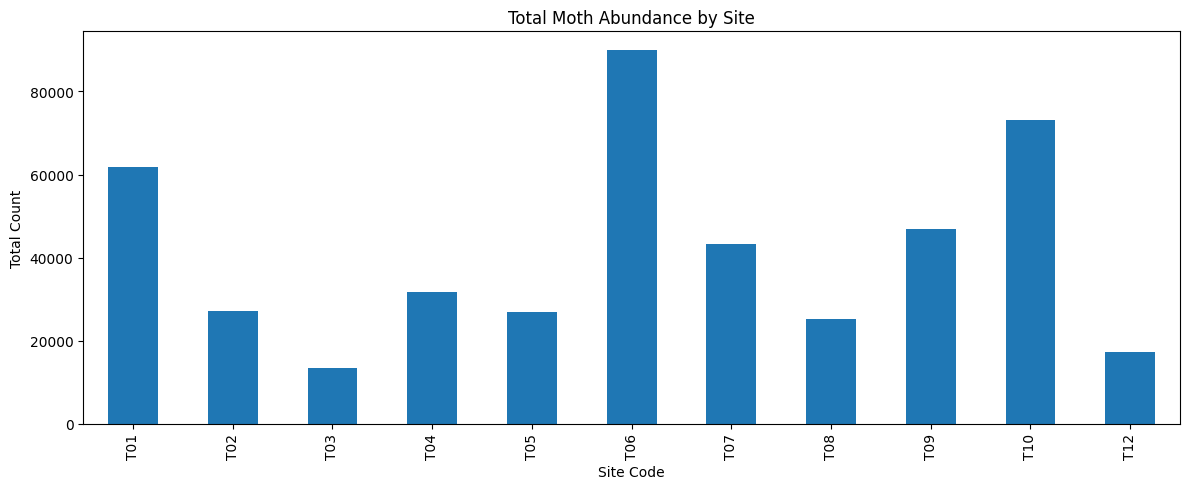

In [3]:
# aggregating counts of each species by site
specs_by_site = df.groupby(['SITECODE', 'FIELDNAME'])['VALUE'].sum().reset_index()

#pivoted for easier visualisation
pivoted = specs_by_site.pivot(index='FIELDNAME', columns='SITECODE', values='VALUE').fillna(0)

# total abundance per site (across all specs)
site_totals = df.groupby('SITECODE')['VALUE'].sum()

# plotting total abundance by site
plt.figure(figsize=(12,5))
site_totals.plot(kind='bar')
plt.title('Total Moth Abundance by Site')
plt.xlabel('Site Code')
plt.ylabel('Total Count')
plt.tight_layout()
plt.show()

### Species Abundance by Year

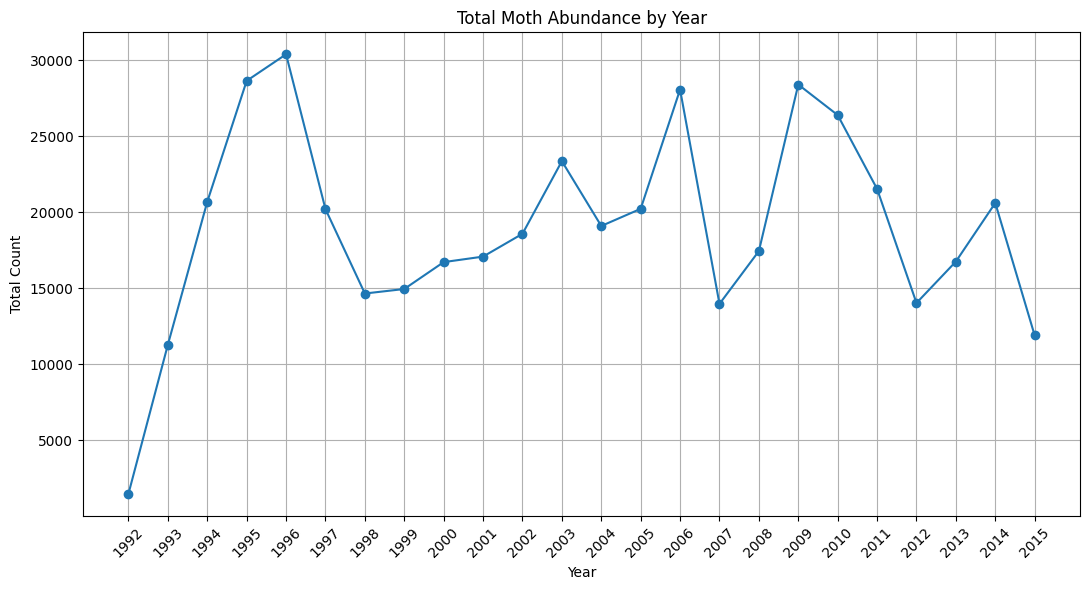

In [4]:
# total abundance of species by yr
species_by_year = df.groupby(['YEAR', 'FIELDNAME'])['VALUE'].sum().reset_index()

# pivoted
pivot_year = species_by_year.pivot(index='FIELDNAME', columns='YEAR', values='VALUE').fillna(0)

pivot_year.head()

# yearly abundance
year_totals = df.groupby('YEAR')['VALUE'].sum()

# plot total abundance per yr
plt.figure(figsize=(11,6))
year_totals.plot(kind='line', marker='o')
plt.title('Total Moth Abundance by Year')
plt.xlabel('Year')
plt.ylabel('Total Count')
plt.xticks(year_totals.index, rotation = 45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Consistency of Species

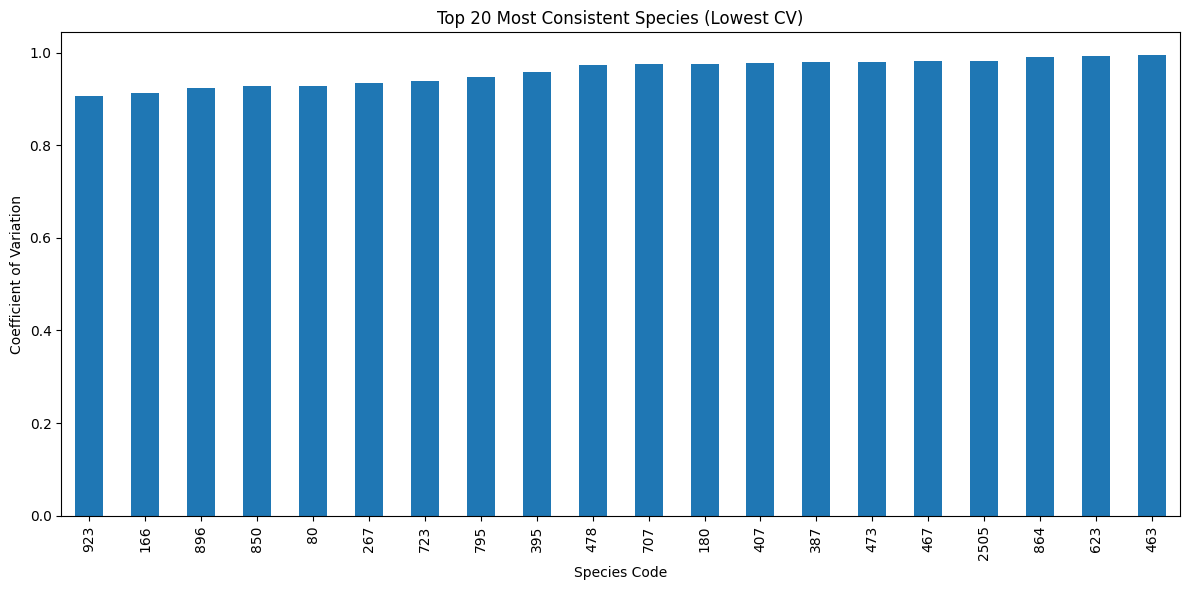

In [5]:
# using mean count per species and standard dev. to calculate this
# using Coeff of variation to measure consistency (s.d./mean, the lower it is, the more consistency)

# making a pivot for species x year (yearly)
spec_year_matrix = df.pivot_table(
    index='FIELDNAME',
    columns='YEAR',
    values='VALUE',
    aggfunc='sum'
).fillna(0)

# dataframe to calc consistency
consistency = pd.DataFrame({
    'mean': spec_year_matrix.mean(axis=1),
    'std': spec_year_matrix.std(axis=1),
    'cv': spec_year_matrix.std(axis=1) / spec_year_matrix.mean(axis=1)
})

# sorting it
consistency_sorted = consistency.sort_values('cv')

# plotting top 10 most consistent species
plt.figure(figsize=(12,6))
consistency_sorted['cv'].head(20).plot(kind='bar')
plt.title('Top 20 Most Consistent Species (Lowest CV)')
plt.ylabel('Coefficient of Variation')
plt.xlabel('Species Code')
plt.tight_layout()
plt.show()


### Year by Year for Top 5 Most Consistent Species

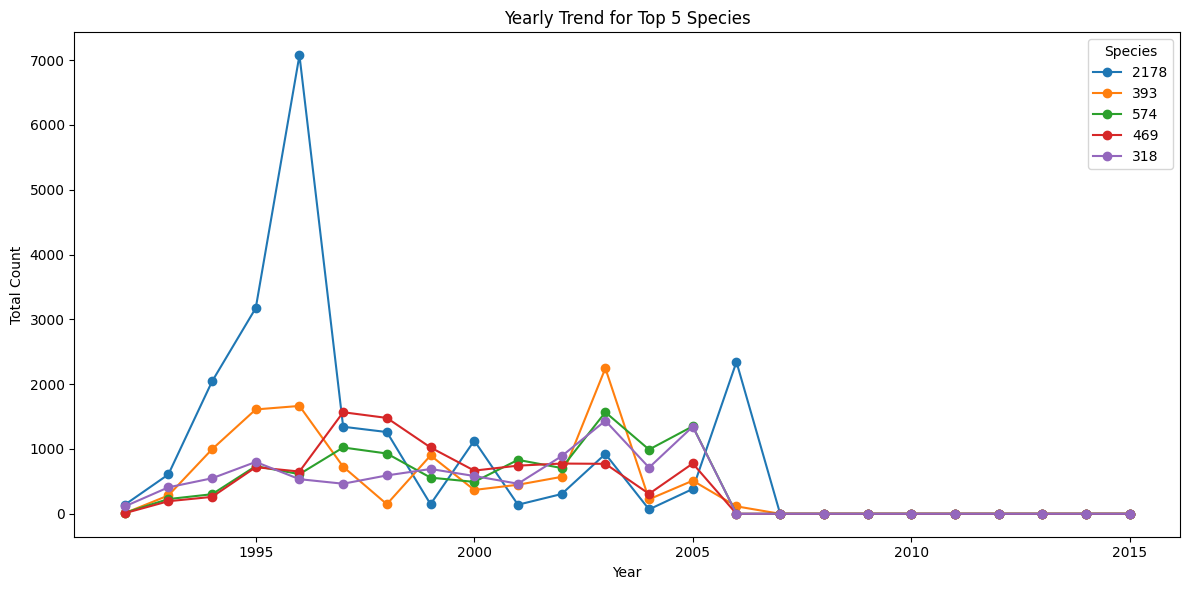

In [6]:
# total abundance of each spec ALL YRS
species_totals = df.groupby('FIELDNAME')['VALUE'].sum().sort_values(ascending=False)

# top 5 most abundant specs
top5 = species_totals.head(5).index

plt.figure(figsize=(12,6))

# plotting
for sp in top5:
    plt.plot(spec_year_matrix.columns, spec_year_matrix.loc[sp], marker='o', label=sp)

plt.title('Yearly Trend for Top 5 Species')
plt.xlabel('Year')
plt.ylabel('Total Count')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

### Total Abundance per Month (all species)

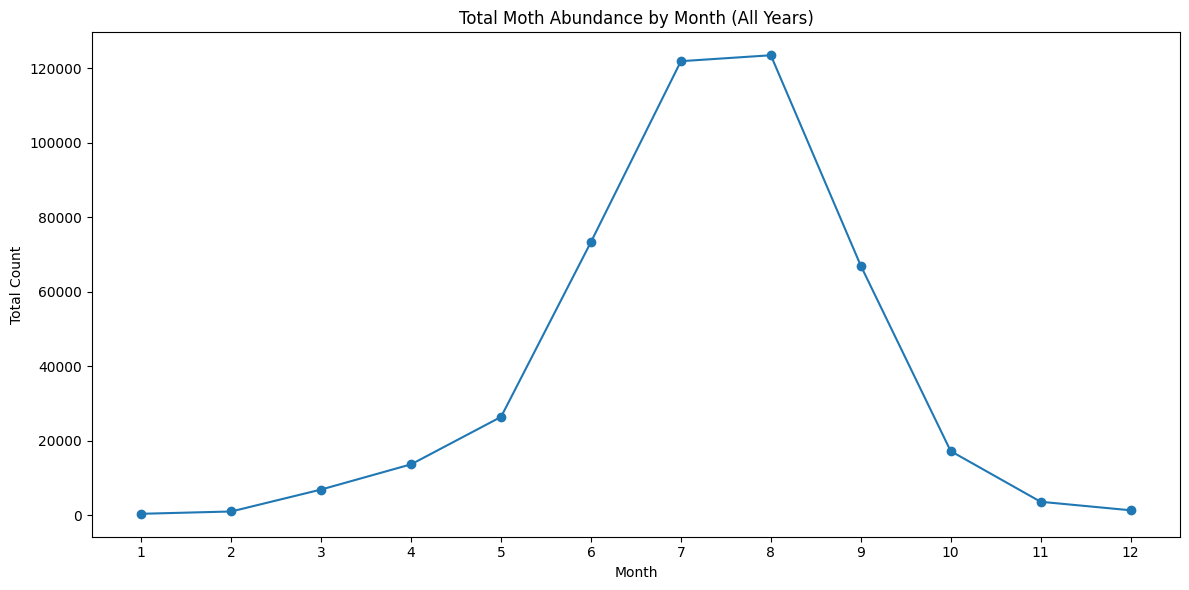

In [7]:
# sum of months abundance across all years
monthly_totals = df.groupby('MONTH')['VALUE'].sum()

monthly_totals

#plotting
plt.figure(figsize=(12,6))
monthly_totals.plot(kind='line', marker='o')
plt.title('Total Moth Abundance by Month (All Years)')
plt.xlabel('Month')
plt.ylabel('Total Count')
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

### Monthly Abundance (by year, all species again)

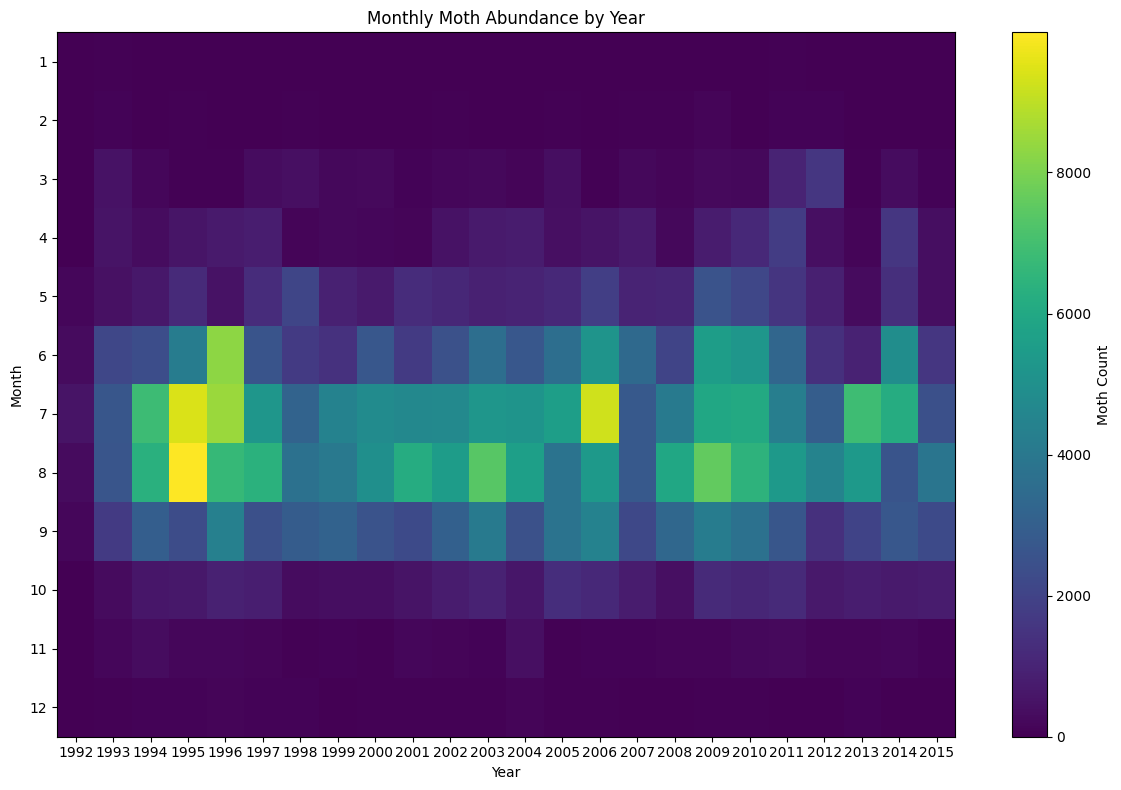

In [8]:
# abundance for each month per year
monthly_year = df.groupby(['YEAR', 'MONTH'])['VALUE'].sum().reset_index()

# pivoted
pivot_month_year = monthly_year.pivot(index='MONTH', columns='YEAR', values='VALUE').fillna(0)
pivot_month_year.head()

# heatmap to show monthly abundance
# will help identify trends across ALL the moth data
plt.figure(figsize=(12,8))
plt.imshow(pivot_month_year, aspect='auto')
plt.colorbar(label='Moth Count')
plt.title('Monthly Moth Abundance by Year')
plt.xlabel('Year')
plt.ylabel('Month')
plt.xticks(ticks=range(len(pivot_month_year.columns)), labels=pivot_month_year.columns)
plt.yticks(ticks=range(12), labels=range(1,13))
plt.tight_layout()
plt.show()


### Line Graph for Each Individual Year Against Months

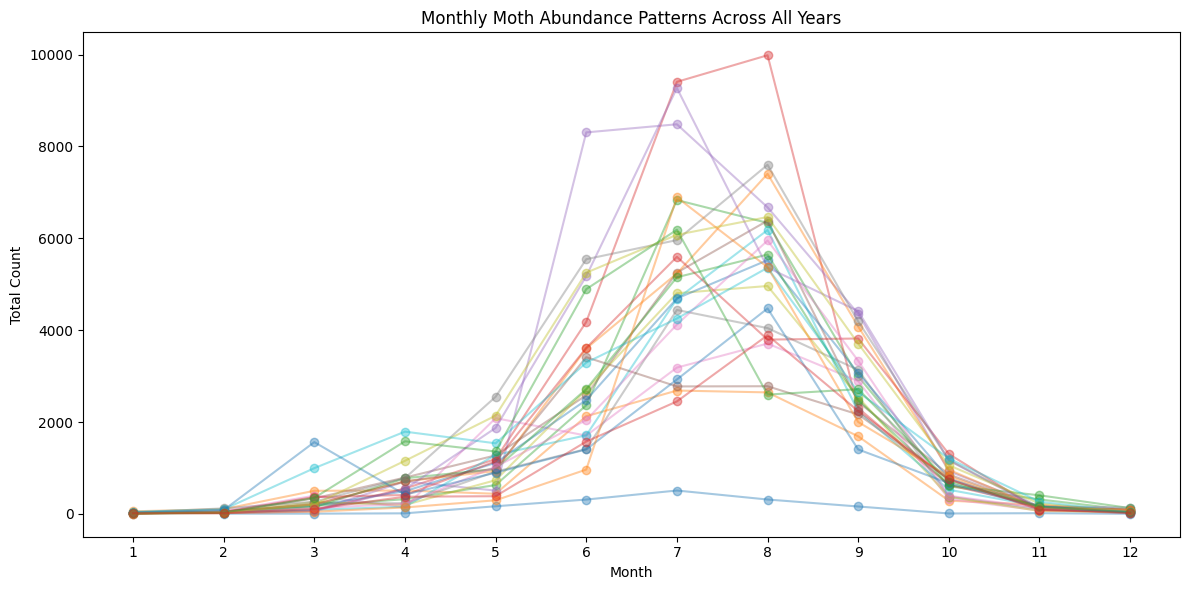

In [9]:
# activating the plot
plt.figure(figsize=(12,6))

# each year for comparison across all months
for year in sorted(df['YEAR'].dropna().unique()):
    subset = df[df['YEAR'] == year]
    m = subset.groupby('MONTH')['VALUE'].sum()
    plt.plot(m.index, m.values, marker='o', alpha=0.4)

plt.title('Monthly Moth Abundance Patterns Across All Years')
plt.xlabel('Month')
plt.ylabel('Total Count')
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

### Monthly Abundance (Species Level)

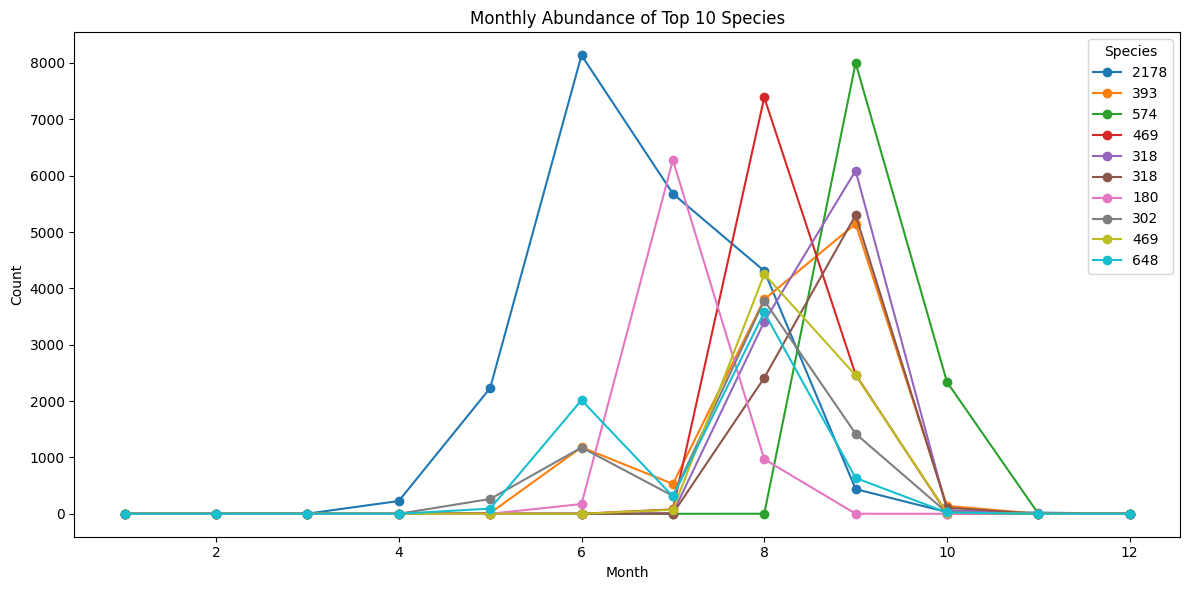

In [10]:
# counts of species for each month
species_month = df.groupby(['FIELDNAME', 'MONTH'])['VALUE'].sum().reset_index()

# pivoted
pivot_species_month = species_month.pivot(index='FIELDNAME', columns='MONTH', values='VALUE').fillna(0)
pivot_species_month.head()

# top 10 species
top10 = df.groupby('FIELDNAME')['VALUE'].sum().sort_values(ascending=False).head(10).index

# plotting
plt.figure(figsize=(12,6))
for sp in top10:
    plt.plot(pivot_species_month.columns, pivot_species_month.loc[sp], marker='o', label=sp)

plt.title('Monthly Abundance of Top 10 Species')
plt.xlabel('Month')
plt.ylabel('Count')
plt.legend(title="Species")
plt.tight_layout()
plt.show()

### Total Moth Abundance by Season

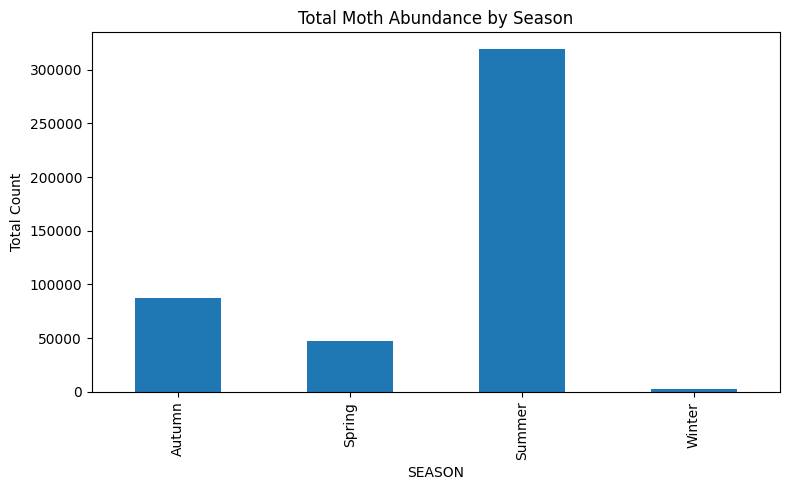

In [11]:
# Winter = December, January, February
# Spring = March, April, May
# Summer = June, July, August
# Autumn = September, Ocotober, November

# function defining szns
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

# created a SEASON column
df['SEASON'] = df['MONTH'].apply(get_season)

# total abundance for each szn
season_totals = df.groupby('SEASON')['VALUE'].sum()

season_totals

# ploting abundance by season
plt.figure(figsize=(8,5))
season_totals.plot(kind='bar')
plt.title('Total Moth Abundance by Season')
plt.ylabel('Total Count')
plt.tight_layout()
plt.show()